In [1]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import mlflow
import mlflow.sklearn
import mlflow.lightgbm
from pathlib import Path
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import roc_auc_score, accuracy_score, confusion_matrix
from sklearn.linear_model import LogisticRegression
from lightgbm import LGBMClassifier
import warnings
warnings.filterwarnings("ignore")

In [2]:
# MLflow setup
PROJECT_ROOT = Path.cwd().resolve().parent
MLFLOW_ROOT = PROJECT_ROOT / "mlflow"
MLFLOW_DB = MLFLOW_ROOT / "mlflow.db"
ARTIFACT_ROOT = MLFLOW_ROOT / "artifacts"

MLFLOW_ROOT.mkdir(exist_ok=True)
ARTIFACT_ROOT.mkdir(exist_ok=True)

mlflow.set_tracking_uri(f"sqlite:///{MLFLOW_DB.as_posix()}")
existing_experiment = mlflow.get_experiment_by_name("home_credit_scoring")

if existing_experiment is None:
    mlflow.create_experiment(
        "home_credit_scoring",
        artifact_location=ARTIFACT_ROOT.as_uri()
    )

mlflow.set_experiment("home_credit_scoring")

print(f"MLflow tracking URI : {mlflow.get_tracking_uri()}")
print(f"Experiment : home_credit_scoring")

experiment = mlflow.get_experiment_by_name("home_credit_scoring")
print(f"artifact_location : {experiment.artifact_location}")

MLflow tracking URI : sqlite:///C:/Users/louis/Documents_locaux/LC_8/mlflow/mlflow.db
Experiment : home_credit_scoring
artifact_location : file:///C:/Users/louis/Documents_locaux/LC_8/mlflow/artifacts


In [3]:
# Chargement du dataset final
DATA_PROCESSED = Path("../data/processed")

train = pd.read_csv(DATA_PROCESSED / "train_final.csv")

X = train.drop("TARGET", axis=1)
y = train["TARGET"].astype(int)

# Retirer SK_ID_CURR — identifiant, pas une feature
X = X.drop("SK_ID_CURR", axis=1)

print(f"X : {X.shape}")
print(f"y : {y.shape}")
print(f"Taux de défaut : {y.mean():.3f}")

X : (307511, 285)
y : (307511,)
Taux de défaut : 0.081


285 features, taux de défaut 8.1% — cohérent avec tout ce qu'on a vu. (On a 287 colonnes dans train_final, moins TARGET et SK_ID_CURR = 285.)

In [4]:
# Fonctions de scoring métier
def business_score(y_true, y_proba, threshold=0.5, fn_cost=10, fp_cost=1):
    """
    Score métier basé sur le coût des erreurs de classification.
    FN (mauvais client prédit bon) : coût fn_cost
    FP (bon client prédit mauvais) : coût fp_cost
    Retourne le coût total normalisé par le nombre de samples.
    """
    y_pred = (y_proba >= threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    
    cost = (fn * fn_cost + fp * fp_cost)
    cost_normalized = cost / len(y_true)
    
    return cost_normalized, fn, fp, tn, tp


def find_optimal_threshold(y_true, y_proba, fn_cost=10, fp_cost=1):
    """
    Cherche le seuil qui minimise le coût métier.
    """
    thresholds = np.arange(0.01, 0.99, 0.01)
    costs = []
    
    for t in thresholds:
        cost, _, _, _, _ = business_score(y_true, y_proba, threshold=t,
                                          fn_cost=fn_cost, fp_cost=fp_cost)
        costs.append(cost)
    
    optimal_idx = np.argmin(costs)
    optimal_threshold = thresholds[optimal_idx]
    optimal_cost = costs[optimal_idx]
    
    return optimal_threshold, optimal_cost, thresholds, costs


# Test rapide
print("Fonctions business_score et find_optimal_threshold définies.")
print(f"Exemple : seuil 0.5, coût FN=10, coût FP=1")

Fonctions business_score et find_optimal_threshold définies.
Exemple : seuil 0.5, coût FN=10, coût FP=1


**business_score**

Prend les vraies étiquettes y_true, les probabilités prédites y_proba et un seuil threshold.

- y_pred = (y_proba >= threshold) — convertit les probabilités en classes 0/1 selon le seuil
- confusion_matrix — retourne une matrice 2×2 qu'on décompose en tn, fp, fn, tp
- cost = fn * 10 + fp * 1 — applique le coût métier : un faux négatif coûte 10 fois plus qu'un faux positif
- cost_normalized — on divise par le nombre de samples pour que le score soit comparable entre des datasets de tailles différentes

**find_optimal_threshold**

Le seuil par défaut à 0.5 n'est pas optimal quand les coûts sont asymétriques. Cette fonction :

- Teste tous les seuils de 0.01 à 0.99 par pas de 0.01
- Calcule le coût métier pour chacun
- Retourne le seuil qui minimise ce coût

Pourquoi le seuil optimal sera probablement bas ?
Avec FN=10 et FP=1, le modèle est fortement pénalisé pour les mauvais clients qu'il laisse passer. Il va donc abaisser le seuil pour être plus conservateur — classer plus de clients comme risqués, quitte à avoir plus de faux positifs. On s'attend à un seuil optimal autour de 0.2-0.3 plutôt que 0.5.

## Stratégie de modélisation

### Modèles à entraîner
1. Régression logistique 
2. LightGBM
3. XGBoost
4. MLP

### Métriques
- Score métier (coût FN=10 × FP) — métrique principale
- AUC-ROC — métrique de contrôle
- Accuracy — métrique de référence

### Validation
- StratifiedKFold (5 folds) — préserve le ratio de classes
- Optimisation du seuil sur chaque fold

### Déséquilibre des classes
- class_weight="balanced" sur la régression logistique
- scale_pos_weight sur LightGBM

### Suite
- Puis choix du meilleur modèle à optimiser avec Optuna 
- Puis fit sur train entier 
- Puis evaluation sur test

In [5]:
# Modèle baseline : Régression Logistique
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Baseline : Régression Logistique
# Pipeline pour scaler avant la régression logistique
lr_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(
        class_weight="balanced",
        max_iter=1000,
        random_state=42
    ))
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Listes pour stocker les résultats par fold
auc_scores    = []
biz_scores    = []
thresholds    = []

with mlflow.start_run(run_name="logistic_regression_baseline"):
    
    mlflow.log_param("model", "LogisticRegression")
    mlflow.log_param("class_weight", "balanced")
    mlflow.log_param("cv_folds", 5)
    mlflow.log_param("fn_cost", 10)
    mlflow.log_param("fp_cost", 1)
    
    for fold, (train_idx, val_idx) in enumerate(cv.split(X, y)):
        X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
        
        lr_pipeline.fit(X_train, y_train)
        y_proba = lr_pipeline.predict_proba(X_val)[:, 1]
        
        # AUC
        auc = roc_auc_score(y_val, y_proba)
        auc_scores.append(auc)
        
        # Seuil optimal et score métier
        opt_threshold, opt_cost, _, _ = find_optimal_threshold(y_val, y_proba)
        biz_scores.append(opt_cost)
        thresholds.append(opt_threshold)
        
        print(f"Fold {fold+1} — AUC: {auc:.4f} | "
              f"Coût métier: {opt_cost:.4f} | "
              f"Seuil optimal: {opt_threshold:.2f}")
    
    # Moyennes
    mean_auc = np.mean(auc_scores)
    mean_biz = np.mean(biz_scores)
    mean_thr = np.mean(thresholds)
    
    mlflow.log_metric("mean_auc",           mean_auc)
    mlflow.log_metric("mean_business_cost", mean_biz)
    mlflow.log_metric("mean_threshold",     mean_thr)
    
    print(f"\nMoyenne — AUC: {mean_auc:.4f} | "
          f"Coût métier: {mean_biz:.4f} | "
          f"Seuil optimal: {mean_thr:.2f}")

Fold 1 — AUC: 0.7607 | Coût métier: 0.5204 | Seuil optimal: 0.50
Fold 2 — AUC: 0.7697 | Coût métier: 0.5106 | Seuil optimal: 0.53
Fold 3 — AUC: 0.7675 | Coût métier: 0.5134 | Seuil optimal: 0.53
Fold 4 — AUC: 0.7704 | Coût métier: 0.5139 | Seuil optimal: 0.51
Fold 5 — AUC: 0.7607 | Coût métier: 0.5284 | Seuil optimal: 0.54

Moyenne — AUC: 0.7658 | Coût métier: 0.5173 | Seuil optimal: 0.52


Bons résultats pour une baseline. Quelques observations :
- AUC à 0.766 — correct pour une régression logistique sur ce dataset. On est loin du risque d'overfitting (< 0.82).
- Seuil optimal autour de 0.52 — surprenant. On attendait un seuil bas (~0.2-0.3) vu le coût asymétrique FN=10. Ça suggère que find_optimal_threshold trouve un équilibre différent de ce qu'on anticipait — à investiguer plus tard.
- Coût métier à 0.517 — c'est notre référence baseline. LightGBM devra faire mieux.

In [6]:
# Nettoyer les noms de colonnes — supprimer les caractères spéciaux pour éviter les problèmes avec LightGBM
X.columns = X.columns.str.replace(r'[^A-Za-z0-9_]', '_', regex=True)
print(f"Colonnes nettoyées : {X.shape[1]}")
print("Exemple :", list(X.columns[:5]))

Colonnes nettoyées : 285
Exemple : ['NAME_CONTRACT_TYPE', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL']


In [7]:
# Modèle avancé : LightGBM
# Ratio pour gérer le déséquilibre des classes
# scale_pos_weight = nb négatifs / nb positifs
scale_pos_weight = (y == 0).sum() / (y == 1).sum()
print(f"scale_pos_weight : {scale_pos_weight:.2f}")

lgbm = LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=31,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    n_jobs=-1,
    verbose=-1
)

auc_scores_lgbm = []
biz_scores_lgbm = []
thresholds_lgbm = []

with mlflow.start_run(run_name="lightgbm_baseline"):
    
    mlflow.log_param("model",             "LightGBM")
    mlflow.log_param("n_estimators",      500)
    mlflow.log_param("learning_rate",     0.05)
    mlflow.log_param("num_leaves",        31)
    mlflow.log_param("scale_pos_weight",  round(scale_pos_weight, 2))
    mlflow.log_param("cv_folds",          5)
    mlflow.log_param("fn_cost",           10)
    mlflow.log_param("fp_cost",           1)
    
    for fold, (train_idx, val_idx) in enumerate(cv.split(X, y)):
        X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
        
        lgbm.fit(X_train, y_train)
        y_proba = lgbm.predict_proba(X_val)[:, 1]
        
        auc = roc_auc_score(y_val, y_proba)
        auc_scores_lgbm.append(auc)
        
        opt_threshold, opt_cost, _, _ = find_optimal_threshold(y_val, y_proba)
        biz_scores_lgbm.append(opt_cost)
        thresholds_lgbm.append(opt_threshold)
        
        print(f"Fold {fold+1} — AUC: {auc:.4f} | "
              f"Coût métier: {opt_cost:.4f} | "
              f"Seuil optimal: {opt_threshold:.2f}")
    
    mean_auc_lgbm = np.mean(auc_scores_lgbm)
    mean_biz_lgbm = np.mean(biz_scores_lgbm)
    mean_thr_lgbm = np.mean(thresholds_lgbm)
    
    mlflow.log_metric("mean_auc",           mean_auc_lgbm)
    mlflow.log_metric("mean_business_cost", mean_biz_lgbm)
    mlflow.log_metric("mean_threshold",     mean_thr_lgbm)
    
    print(f"\nMoyenne — AUC: {mean_auc_lgbm:.4f} | "
          f"Coût métier: {mean_biz_lgbm:.4f} | "
          f"Seuil optimal: {mean_thr_lgbm:.2f}")

scale_pos_weight : 11.39
Fold 1 — AUC: 0.7750 | Coût métier: 0.5017 | Seuil optimal: 0.48
Fold 2 — AUC: 0.7837 | Coût métier: 0.4937 | Seuil optimal: 0.51
Fold 3 — AUC: 0.7778 | Coût métier: 0.5009 | Seuil optimal: 0.51
Fold 4 — AUC: 0.7824 | Coût métier: 0.4890 | Seuil optimal: 0.50
Fold 5 — AUC: 0.7744 | Coût métier: 0.5070 | Seuil optimal: 0.49

Moyenne — AUC: 0.7786 | Coût métier: 0.4985 | Seuil optimal: 0.50


LightGBM améliore clairement la baseline.

## Comparaison

| Modèle                            | AUC   | Coût métier | Seuil |
|-----------------------------------|-------|-------------|-------|
| Régression Logistique (baseline)  | 0.765 | 0.5173      | 0.52  |
| LightGBM                          | 0.778 | 0.4985      | 0.50  |

👉 **+0.013 AUC et -0.019 coût métier** — LightGBM est meilleur sur les deux métriques.

---

Le seuil optimal reste autour de **0.50** sur les deux modèles — c'est intriguant vu le coût asymétrique.  
On reviendra là-dessus après l'optimisation des hyperparamètres.

---

On est à **AUC = 0.778** — en dessous du seuil d'alerte overfitting de **0.82** mentionné dans l'énoncé.  
👉 Bon signe.

In [8]:
# Comparaison : XGBoost
# Elle sert à comparer un autre modèle d’arbres, proche de LightGBM mais avec un comportement un peu différent.
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=400,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=1,
    reg_alpha=0.0,
    reg_lambda=1.0,
    scale_pos_weight=scale_pos_weight,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

auc_scores_xgb = []
biz_scores_xgb = []
thresholds_xgb = []

with mlflow.start_run(run_name="xgboost_baseline"):
    mlflow.log_param("model", "XGBoost")
    mlflow.log_param("n_estimators", 400)
    mlflow.log_param("max_depth", 6)
    mlflow.log_param("learning_rate", 0.05)
    mlflow.log_param("subsample", 0.8)
    mlflow.log_param("colsample_bytree", 0.8)
    mlflow.log_param("scale_pos_weight", round(scale_pos_weight, 2))
    mlflow.log_param("cv_folds", 5)
    mlflow.log_param("fn_cost", 10)
    mlflow.log_param("fp_cost", 1)

    for fold, (train_idx, val_idx) in enumerate(cv.split(X, y)):
        X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

        xgb.fit(X_train, y_train)
        y_proba = xgb.predict_proba(X_val)[:, 1]

        auc = roc_auc_score(y_val, y_proba)
        auc_scores_xgb.append(auc)

        opt_threshold, opt_cost, _, _ = find_optimal_threshold(y_val, y_proba)
        biz_scores_xgb.append(opt_cost)
        thresholds_xgb.append(opt_threshold)

        print(f"Fold {fold+1} - AUC: {auc:.4f} | Cout metier: {opt_cost:.4f} | Seuil optimal: {opt_threshold:.2f}")

    mean_auc_xgb = np.mean(auc_scores_xgb)
    mean_biz_xgb = np.mean(biz_scores_xgb)
    mean_thr_xgb = np.mean(thresholds_xgb)

    mlflow.log_metric("mean_auc", mean_auc_xgb)
    mlflow.log_metric("mean_business_cost", mean_biz_xgb)
    mlflow.log_metric("mean_threshold", mean_thr_xgb)

    print(f"\nMoyenne - AUC: {mean_auc_xgb:.4f} | Cout metier: {mean_biz_xgb:.4f} | Seuil optimal: {mean_thr_xgb:.2f}")


Fold 1 - AUC: 0.7749 | Cout metier: 0.5019 | Seuil optimal: 0.48
Fold 2 - AUC: 0.7828 | Cout metier: 0.4938 | Seuil optimal: 0.49
Fold 3 - AUC: 0.7762 | Cout metier: 0.5030 | Seuil optimal: 0.47
Fold 4 - AUC: 0.7818 | Cout metier: 0.4933 | Seuil optimal: 0.46
Fold 5 - AUC: 0.7741 | Cout metier: 0.5111 | Seuil optimal: 0.51

Moyenne - AUC: 0.7780 | Cout metier: 0.5006 | Seuil optimal: 0.48


In [9]:
# Comparaison : MLP
# On teste ici plusieurs fonctions d'activation pour justifier le choix final du MLP.
# Comme le MLP est sensible a l'echelle des variables, on garde StandardScaler dans une Pipeline.

from sklearn.neural_network import MLPClassifier
from sklearn.utils.class_weight import compute_sample_weight

activation_functions = {
    "relu": "ReLU - max(0, x). Rapide, souvent le meilleur choix par defaut sur donnees tabulaires.",
    "tanh": "Tanh - sortie dans [-1, 1]. Peut bien fonctionner sur des reseaux modestes.",
    "logistic": "Sigmoid - sortie dans [0, 1]. Souvent plus lent et moins performant en couches cachees.",
}

mlp_results = {}

for activation, description in activation_functions.items():
    mlp_pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", MLPClassifier(
            hidden_layer_sizes=(128, 64),
            activation=activation,
            alpha=0.0005,
            learning_rate_init=0.001,
            early_stopping=True,
            validation_fraction=0.1,
            n_iter_no_change=10,
            max_iter=200,
            random_state=42
        ))
    ])

    auc_scores_mlp = []
    biz_scores_mlp = []
    thresholds_mlp = []
    epochs_mlp = []

    with mlflow.start_run(run_name=f"mlp_activation_{activation}"):
        mlflow.log_param("model", "MLPClassifier")
        mlflow.log_param("activation", activation)
        mlflow.log_param("hidden_layer_sizes", "(128, 64)")
        mlflow.log_param("alpha", 0.0005)
        mlflow.log_param("learning_rate_init", 0.001)
        mlflow.log_param("early_stopping", True)
        mlflow.log_param("validation_fraction", 0.1)
        mlflow.log_param("n_iter_no_change", 10)
        mlflow.log_param("max_iter", 200)
        mlflow.log_param("cv_folds", 5)
        mlflow.log_param("fn_cost", 10)
        mlflow.log_param("fp_cost", 1)

        for fold, (train_idx, val_idx) in enumerate(cv.split(X, y), start=1):
            X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
            y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

            sample_weight = compute_sample_weight(class_weight="balanced", y=y_train)
            mlp_pipeline.fit(X_train, y_train, clf__sample_weight=sample_weight)
            y_proba = mlp_pipeline.predict_proba(X_val)[:, 1]

            auc = roc_auc_score(y_val, y_proba)
            auc_scores_mlp.append(auc)

            opt_threshold, opt_cost, _, _ = find_optimal_threshold(y_val, y_proba)
            biz_scores_mlp.append(opt_cost)
            thresholds_mlp.append(opt_threshold)

            n_epochs = mlp_pipeline.named_steps["clf"].n_iter_
            epochs_mlp.append(n_epochs)

            print(
                f"MLP ({activation:10s}) | Fold {fold} - "
                f"AUC: {auc:.4f} | Cout metier: {opt_cost:.4f} | "
                f"Seuil optimal: {opt_threshold:.2f} | Epochs: {n_epochs}"
            )

        mean_auc_activation = np.mean(auc_scores_mlp)
        std_auc_activation = np.std(auc_scores_mlp)
        mean_biz_activation = np.mean(biz_scores_mlp)
        mean_thr_activation = np.mean(thresholds_mlp)
        mean_epochs_activation = np.mean(epochs_mlp)

        mlflow.log_metric("mean_auc", mean_auc_activation)
        mlflow.log_metric("std_auc", std_auc_activation)
        mlflow.log_metric("mean_business_cost", mean_biz_activation)
        mlflow.log_metric("mean_threshold", mean_thr_activation)
        mlflow.log_metric("mean_epochs", mean_epochs_activation)
        mlflow.set_tag("model_type", "MLP")
        mlflow.set_tag("activation_function", activation)

        mlp_results[activation] = {
            "mean_auc": mean_auc_activation,
            "std_auc": std_auc_activation,
            "mean_business_cost": mean_biz_activation,
            "mean_threshold": mean_thr_activation,
            "mean_epochs": mean_epochs_activation,
            "description": description,
        }

print("\n" + "=" * 70)
print("COMPARAISON DES FONCTIONS D'ACTIVATION")
print("=" * 70)

mlp_activation_comparison = (
    pd.DataFrame(mlp_results)
    .T
    .sort_values(["mean_business_cost", "mean_auc"], ascending=[True, False])
)

display(mlp_activation_comparison.round(4))

best_activation = mlp_activation_comparison.index[0]
mean_auc_mlp = mlp_activation_comparison.loc[best_activation, "mean_auc"]
mean_biz_mlp = mlp_activation_comparison.loc[best_activation, "mean_business_cost"]
mean_thr_mlp = mlp_activation_comparison.loc[best_activation, "mean_threshold"]

print(f"\nMeilleure activation : {best_activation}")
print(f"Raison : cout metier moyen le plus bas ({mean_biz_mlp:.4f})")
print(mlp_results[best_activation]["description"])


MLP (relu      ) | Fold 1 - AUC: 0.7545 | Cout metier: 0.5324 | Seuil optimal: 0.51 | Epochs: 14
MLP (relu      ) | Fold 2 - AUC: 0.7638 | Cout metier: 0.5182 | Seuil optimal: 0.56 | Epochs: 14
MLP (relu      ) | Fold 3 - AUC: 0.7609 | Cout metier: 0.5216 | Seuil optimal: 0.54 | Epochs: 13
MLP (relu      ) | Fold 4 - AUC: 0.7636 | Cout metier: 0.5217 | Seuil optimal: 0.55 | Epochs: 14
MLP (relu      ) | Fold 5 - AUC: 0.7578 | Cout metier: 0.5330 | Seuil optimal: 0.51 | Epochs: 14
MLP (tanh      ) | Fold 1 - AUC: 0.7473 | Cout metier: 0.5402 | Seuil optimal: 0.54 | Epochs: 14
MLP (tanh      ) | Fold 2 - AUC: 0.7580 | Cout metier: 0.5273 | Seuil optimal: 0.53 | Epochs: 15
MLP (tanh      ) | Fold 3 - AUC: 0.7579 | Cout metier: 0.5263 | Seuil optimal: 0.51 | Epochs: 13
MLP (tanh      ) | Fold 4 - AUC: 0.7587 | Cout metier: 0.5283 | Seuil optimal: 0.52 | Epochs: 12
MLP (tanh      ) | Fold 5 - AUC: 0.7504 | Cout metier: 0.5401 | Seuil optimal: 0.50 | Epochs: 13
MLP (logistic  ) | Fold 1 - AU

,mean_auc,std_auc,mean_business_cost,mean_threshold,mean_epochs,description
logistic,0.765524,0.004399,0.516264,0.526,19.6,"Sigmoid - sortie dans [0, 1]. Souvent plus len..."
relu,0.760115,0.003567,0.525383,0.534,13.8,"ReLU - max(0, x). Rapide, souvent le meilleur ..."
tanh,0.754438,0.004706,0.532439,0.52,13.4,"Tanh - sortie dans [-1, 1]. Peut bien fonction..."



Meilleure activation : logistic
Raison : cout metier moyen le plus bas (0.5163)
Sigmoid - sortie dans [0, 1]. Souvent plus lent et moins performant en couches cachees.


L’exploration des fonctions d’activation montre que logistic obtient les meilleurs résultats sur le MLP, à la fois en AUC et en coût métier. Bien que relu converge plus rapidement, il est légèrement moins performant. tanh est l’activation la moins convaincante dans cette comparaison. Nous retenons donc logistic comme activation pour le modèle MLP final.

Ce résultat montre qu’un choix par défaut (relu) n’est pas toujours optimal. Même sur un réseau simple, il est utile de valider expérimentalement certains hyperparamètres structurants.

## Tableau comparatif 

| Modèle                           | AUC    | Coût métier | Seuil |
|----------------------------------|--------|-------------|-------|
| LightGBM baseline                | 0.7786 | 0.4985      | 0.498 |
| XGBoost baseline                 | 0.7780 | 0.5010      | 0.482 |
| Baseline (Régression Logistique) | 0.7658 | 0.5173      | 0.522 |
| MLP (logistic)                   | 0.7655 | 0.5162      | 0.526 |

On retiendra LightGBM pour l'optimisation

In [10]:
# Hyperparameter tuning avec Optuna
# en testant plusieurs combinaisons (n_estimators, num_leaves, learning_rate, etc.) et en gardant celle qui donne le meilleur AUC moyen en validation croisée.
import optuna
from optuna.samplers import TPESampler

optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective(trial):
    params = {
        "n_estimators"      : trial.suggest_int("n_estimators", 200, 1000),
        "num_leaves"        : trial.suggest_int("num_leaves", 20, 150),
        "learning_rate"     : trial.suggest_float("learning_rate", 0.01, 0.1, log=True),
        "min_child_samples" : trial.suggest_int("min_child_samples", 10, 100),
        "subsample"         : trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree"  : trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "reg_alpha"         : trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True),
        "reg_lambda"        : trial.suggest_float("reg_lambda", 1e-8, 10.0, log=True),
    }

    model = LGBMClassifier(
        **params,
        scale_pos_weight=scale_pos_weight,
        random_state=42,
        n_jobs=-1,
        verbose=-1
    )

    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    auc_scores = []

    for train_idx, val_idx in cv.split(X, y):
        X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

        model.fit(X_train, y_train)
        y_proba = model.predict_proba(X_val)[:, 1]
        auc_scores.append(roc_auc_score(y_val, y_proba))

    return np.mean(auc_scores)


study = optuna.create_study(
    direction="maximize",
    sampler=TPESampler(seed=42)
)

print("Lancement Optuna — 50 essais...")
study.optimize(objective, n_trials=50, show_progress_bar=True)

print(f"\nMeilleur AUC     : {study.best_value:.4f}")
print(f"Meilleurs params : {study.best_params}")

Lancement Optuna — 50 essais...


Best trial: 3. Best value: 0.779271:  16%|█▌        | 8/50 [6:13:58<32:43:24, 2804.87s/it]


[W 2026-05-01 07:14:02,451] Trial 8 failed with parameters: {'n_estimators': 425, 'num_leaves': 91, 'learning_rate': 0.013833249975219963, 'min_child_samples': 82, 'subsample': 0.6298202574719083, 'colsample_bytree': 0.9947547746402069, 'reg_alpha': 0.08916674715636537, 'reg_lambda': 6.143857495033091e-07} because of the following error: KeyboardInterrupt().
Traceback (most recent call last):
  File "c:\Users\louis\Documents_locaux\LC_8\.venv\Lib\site-packages\optuna\study\_optimize.py", line 206, in _run_trial
    value_or_values = func(trial)
  File "C:\Users\louis\AppData\Local\Temp\ipykernel_41456\545957436.py", line 35, in objective
    model.fit(X_train, y_train)
    ~~~~~~~~~^^^^^^^^^^^^^^^^^^
  File "c:\Users\louis\Documents_locaux\LC_8\.venv\Lib\site-packages\lightgbm\sklearn.py", line 1560, in fit
    super().fit(
    ~~~~~~~~~~~^
        X,
        ^^
    ...<12 lines>...
        init_model=init_model,
        ^^^^^^^^^^^^^^^^^^^^^^
    )
    ^
  File "c:\Users\louis\Documen

KeyboardInterrupt: 

AUC 0.7805 — légère amélioration par rapport au LightGBM avant optimisation (0.7786). Le meilleur essai a été trouvé dès le 12ème essai sur 50, ce qui montre qu'Optuna a bien convergé.
Paramètres notables :

- n_estimators à 993 — beaucoup d'arbres, compensé par un learning_rate bas à 0.018
- num_leaves à 64 — arbres plus complexes que le défaut (31)
- reg_alpha élevé à 9.15 — forte régularisation L1, limite l'overfitting

In [ ]:
# Optimisation LightGBM sur le cout metier avec Optuna
# Version allegee pour comparer rapidement avec l'optimisation sur l'AUC

import optuna
from optuna.samplers import TPESampler

optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective_business_cost(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 200, 700, step=100),
        "num_leaves": trial.suggest_int("num_leaves", 20, 100, step=10),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.1, log=True),
        "min_child_samples": trial.suggest_int("min_child_samples", 10, 60, step=10),
        "subsample": trial.suggest_float("subsample", 0.7, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.7, 1.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-6, 1.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-6, 1.0, log=True),
    }

    model = LGBMClassifier(
        **params,
        scale_pos_weight=scale_pos_weight,
        random_state=42,
        n_jobs=-1,
        verbose=-1
    )

    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

    business_costs = []

    for train_idx, val_idx in cv.split(X, y):
        X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

        model.fit(X_train, y_train)
        y_proba = model.predict_proba(X_val)[:, 1]

        opt_threshold, opt_cost, _, _ = find_optimal_threshold(
            y_val, y_proba, fn_cost=10, fp_cost=1
        )
        business_costs.append(opt_cost)

    return np.mean(business_costs)


study_business = optuna.create_study(
    direction="minimize",
    sampler=TPESampler(seed=42)
)

print("Lancement Optuna cout metier - 15 essais...")
study_business.optimize(objective_business_cost, n_trials=15, show_progress_bar=True)

print(f"\nMeilleur cout metier : {study_business.best_value:.4f}")
print(f"Meilleurs params     : {study_business.best_params}")

Lancement Optuna cout metier - 15 essais...


  0%|          | 0/15 [00:00<?, ?it/s]


Meilleur cout metier : 0.5003
Meilleurs params     : {'n_estimators': 600, 'num_leaves': 50, 'learning_rate': 0.023445856216377303, 'min_child_samples': 20, 'subsample': 0.8368609183148666, 'colsample_bytree': 0.7910338902665673, 'reg_alpha': 1.829990488582394e-05, 'reg_lambda': 0.009216724067410252}


L’optimisation des hyperparamètres sur l’AUC et sur le coût métier conduit à des configurations proches. Cela suggère que, sur ce dataset, maximiser l’AUC constitue déjà un bon proxy de l’objectif métier. L’optimisation directe sur le coût métier affine légèrement l’alignement avec le besoin opérationnel, sans changer fortement la structure du modèle retenu.

Par souci de cohérence métier, l’optimisation sur le coût métier est la plus alignée avec l’objectif final. Toutefois, les résultats proches obtenus avec l’optimisation sur l’AUC confirment la robustesse du modèle LightGBM.

In [ ]:
# Entraînement du modèle final avec les meilleurs hyperparamètres
# On réentraîne un modèle LightGBM avec les meilleurs hyperparamètres trouvés par Optuna, puis on évalue à nouveau en validation croisée pour obtenir les métriques finales (business_cost, threshold).
best_params = study.best_params

lgbm_final = LGBMClassifier(
    **best_params,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    n_jobs=-1,
    verbose=-1
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

auc_scores_final  = []
biz_scores_final  = []
thresholds_final  = []

with mlflow.start_run(run_name="lightgbm_optuna_optimized"):

    mlflow.log_params(best_params)
    mlflow.log_param("model",            "LightGBM")
    mlflow.log_param("scale_pos_weight", round(scale_pos_weight, 2))
    mlflow.log_param("cv_folds",         5)
    mlflow.log_param("fn_cost",          10)
    mlflow.log_param("fp_cost",          1)

    for fold, (train_idx, val_idx) in enumerate(cv.split(X, y)):
        X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

        lgbm_final.fit(X_train, y_train)
        y_proba = lgbm_final.predict_proba(X_val)[:, 1]

        auc = roc_auc_score(y_val, y_proba)
        auc_scores_final.append(auc)

        opt_threshold, opt_cost, _, _ = find_optimal_threshold(y_val, y_proba)
        biz_scores_final.append(opt_cost)
        thresholds_final.append(opt_threshold)

        print(f"Fold {fold+1} — AUC: {auc:.4f} | "
              f"Coût métier: {opt_cost:.4f} | "
              f"Seuil optimal: {opt_threshold:.2f}")

    mean_auc_final = np.mean(auc_scores_final)
    mean_biz_final = np.mean(biz_scores_final)
    mean_thr_final = np.mean(thresholds_final)

    mlflow.log_metric("mean_auc",           mean_auc_final)
    mlflow.log_metric("mean_business_cost", mean_biz_final)
    mlflow.log_metric("mean_threshold",     mean_thr_final)

    print(f"\nMoyenne — AUC: {mean_auc_final:.4f} | "
          f"Coût métier: {mean_biz_final:.4f} | "
          f"Seuil optimal: {mean_thr_final:.2f}")

Fold 1 — AUC: 0.7788 | Coût métier: 0.4973 | Seuil optimal: 0.46
Fold 2 — AUC: 0.7861 | Coût métier: 0.4892 | Seuil optimal: 0.47
Fold 3 — AUC: 0.7806 | Coût métier: 0.4937 | Seuil optimal: 0.47
Fold 4 — AUC: 0.7833 | Coût métier: 0.4897 | Seuil optimal: 0.50
Fold 5 — AUC: 0.7778 | Coût métier: 0.5051 | Seuil optimal: 0.48

Moyenne — AUC: 0.7813 | Coût métier: 0.4950 | Seuil optimal: 0.48


In [ ]:
comparison_results = pd.DataFrame([
    {"Model": "LogisticRegression baseline", "AUC": mean_auc, "BusinessCost": mean_biz, "Threshold": mean_thr},
    {"Model": "LightGBM baseline", "AUC": mean_auc_lgbm, "BusinessCost": mean_biz_lgbm, "Threshold": mean_thr_lgbm},
    {"Model": "LightGBM Optuna (AUC)", "AUC": mean_auc_final, "BusinessCost": mean_biz_final, "Threshold": mean_thr_final},
    {"Model": "XGBoost baseline", "AUC": mean_auc_xgb, "BusinessCost": mean_biz_xgb, "Threshold": mean_thr_xgb},
    {"Model": "MLP (logistic)", "AUC": mean_auc_mlp, "BusinessCost": mean_biz_mlp, "Threshold": mean_thr_mlp},
]).sort_values(["BusinessCost", "AUC"], ascending=[True, False]).reset_index(drop=True)

comparison_results


,Model,AUC,BusinessCost,Threshold
0,LightGBM Optuna (AUC),0.781344,0.494981,0.476
1,LightGBM baseline,0.778646,0.498467,0.498
2,XGBoost baseline,0.777951,0.500600,0.482
3,MLP (logistic),0.765524,0.516264,0.526
4,LogisticRegression baseline,0.765784,0.517328,0.522


## Tableau comparatif complet

| Modèle                           | AUC    | Coût métier | Seuil |
|----------------------------------|--------|-------------|-------|
| LightGBM Optuna (AUC)            | 0.7813 | 0.4949      | 0.476 |
| LightGBM baseline                | 0.7786 | 0.4985      | 0.498 |
| XGBoost baseline                 | 0.7780 | 0.5010      | 0.482 |
| MLP (logistic)                   | 0.7655 | 0.5163      | 0.526 |
| Baseline (Régression Logistique) | 0.7658 | 0.5173      | 0.522 |

---

## Deux améliorations notables

- **LightGBM Optuna** reste le meilleur modèle sur les deux critères principaux :
  AUC = **0.7813** et coût métier = **0.4949**.

- **XGBoost** est proche de LightGBM baseline en AUC, mais reste légèrement moins bon en coût métier.
  Il n’apporte donc pas de gain concret par rapport à LightGBM.

- **MLP** décevant :
  Pas beaucoup mieux qu'une régression logistique.

---

## Conclusion

Le meilleur compromis pour la suite est **LightGBM optimisé avec Optuna (sur l'AUC)**.

C’est le modèle qui :
- maximise l’AUC
- minimise le coût métier
- reste cohérent avec l’objectif business défini

On peut donc le retenir pour l’évaluation finale sur `test_final.csv` et pour la suite du pipeline.


In [ ]:
# On entraîne sur 100% du train pour le modèle de production
lgbm_production = LGBMClassifier(
    **best_params,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    n_jobs=-1,
    verbose=-1
)

lgbm_production.fit(X, y)
print("Modèle entraîné sur 100% du dataset.")

# Enregistrement dans le model registry MLflow
with mlflow.start_run(run_name="lightgbm_production"):
    mlflow.log_params(best_params)
    mlflow.log_metric("mean_auc",           mean_auc_final)
    mlflow.log_metric("mean_business_cost", mean_biz_final)
    mlflow.log_metric("mean_threshold",     mean_thr_final)
    
    mlflow.lightgbm.log_model(
        lgbm_production,
        name="model", # 2026/04/02 13:23:50 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
        registered_model_name="home_credit_scoring"
    )
    
    print(f"Modèle enregistré dans le registry MLflow.")
    print(f"Run ID : {mlflow.active_run().info.run_id}")

Modèle entraîné sur 100% du dataset.


2026/04/02 16:45:17 WARNING mlflow.lightgbm: Saving the models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/04/02 16:45:40 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


Modèle enregistré dans le registry MLflow.
Run ID : 9309957622c74a168a48a210593e144d


Successfully registered model 'home_credit_scoring'.
Created version '1' of model 'home_credit_scoring'.


Pour lancer MLFlow UI : 

uv run mlflow ui --backend-store-uri sqlite:///mlflow/mlflow.db

http://127.0.0.1:5000

## Conclusion d'entrainement

Ce notebook a permis de comparer plusieurs approches de classification pour le scoring crédit : régression logistique, LightGBM, XGBoost et MLP.

Les résultats montrent que **LightGBM** est le modèle le plus performant sur ce projet. Il obtient le meilleur compromis entre **AUC** et **coût métier**, devant XGBoost, la régression logistique et le MLP. L’optimisation des hyperparamètres avec **Optuna** a permis d’améliorer légèrement les performances du modèle baseline.

Deux stratégies d’optimisation ont été testées pour LightGBM :
- une optimisation sur l’**AUC** ;
- une optimisation sur le **coût métier**.

Les configurations obtenues sont restées proches, ce qui suggère que, sur ce dataset, l’AUC constitue un bon proxy de l’objectif métier. L’optimisation directe sur le coût métier reste toutefois la plus alignée avec le besoin opérationnel.

Côté réseau de neurones, l’exploration des fonctions d’activation a montré que **`logistic`** donne de meilleurs résultats que `relu` et `tanh` dans cette configuration. Malgré cela, le MLP reste moins performant que les modèles de boosting sur ces données tabulaires.

Le modèle final retenu est donc un **LightGBM optimisé**, réentraîné sur **100 % des données**, puis enregistré dans le **Model Registry MLflow** sous le nom `home_credit_scoring`. Cette dernière étape permet de tracer, versionner et préparer le modèle pour la suite du projet, notamment son déploiement via l’API.


In [ ]:
# Prediction sur test_final.csv avec le modele final

import pandas as pd
from pathlib import Path
import re

# 1. Identifier la racine du projet
root = Path.cwd()
if not (root / "data").exists():
    root = root.parent

# 2. Charger le jeu de test final
test_path = root / "data" / "processed" / "test_final.csv"
print("Chemin utilise :", test_path)
print("Existe :", test_path.exists())

test_final = pd.read_csv(test_path)
print(f"Shape test_final : {test_final.shape}")
display(test_final.head())

# 3. Recuperer l'identifiant client
id_col = "SK_ID_CURR"
test_ids = test_final[id_col].copy()

# 4. Construire la matrice de features
X_test_final = test_final.drop(columns=[id_col]).copy()

# 5. Appliquer le meme nettoyage de noms de colonnes que celui utilise pour X
def clean_column_name(col):
    col = str(col)
    col = col.replace(" / ", "___")
    col = col.replace("/", "___")
    col = col.replace(", ", "__")
    col = col.replace(",", "__")
    col = col.replace(" ", "_")
    col = col.replace("(", "")
    col = col.replace(")", "")
    col = col.replace("-", "_")
    col = re.sub(r"[^0-9a-zA-Z_]", "_", col)
    col = re.sub(r"_+", "_", col).strip("_")
    return col

X_test_final.columns = [clean_column_name(col) for col in X_test_final.columns]

# Harmonisation supplementaire :
# certaines colonnes de X utilisent des doubles ou triples underscores
# alors que test_final nettoye les reduit a un seul underscore.
# On reconcilie ces noms automatiquement.

def normalize_for_match(col):
    return re.sub(r"_+", "_", col)

rename_map = {}
x_cols_by_normalized = {normalize_for_match(col): col for col in X.columns}

for col in X_test_final.columns:
    normalized = normalize_for_match(col)
    if col not in X.columns and normalized in x_cols_by_normalized:
        rename_map[col] = x_cols_by_normalized[normalized]

X_test_final = X_test_final.rename(columns=rename_map)

# 6. Aligner les colonnes sur celles du train
missing_cols = [col for col in X.columns if col not in X_test_final.columns]
extra_cols = [col for col in X_test_final.columns if col not in X.columns]

print(f"Nombre de colonnes manquantes : {len(missing_cols)}")
print(f"Nombre de colonnes en trop    : {len(extra_cols)}")

if missing_cols:
    print("Exemples colonnes manquantes :", missing_cols[:10])

if extra_cols:
    print("Exemples colonnes en trop    :", extra_cols[:10])

# 7. Ajouter les colonnes manquantes a 0
for col in missing_cols:
    X_test_final[col] = 0

# 8. Garder uniquement les colonnes attendues, dans le bon ordre
X_test_final = X_test_final[X.columns]

print(f"Shape apres alignement : {X_test_final.shape}")

# 9. Predire les probabilites
y_proba_final = lgbm_production.predict_proba(X_test_final)[:, 1]

# 10. Appliquer le seuil retenu
final_threshold = 0.476
y_pred_final = (y_proba_final >= final_threshold).astype(int)

# 11. Construire le tableau final
predictions = pd.DataFrame({
    "SK_ID_CURR": test_ids,
    "prediction_proba": y_proba_final,
    "prediction_label": y_pred_final
})

display(predictions.head())

# 12. Sauvegarder
output_path = root / "data" / "processed" / "test_final_predictions.csv"
predictions.to_csv(output_path, index=False)

print(f"Predictions sauvegardees : {output_path}")


Chemin utilise : c:\Users\louis\Documents_locaux\OC_6\data\processed\test_final.csv
Existe : True
Shape test_final : (48744, 286)


,SK_ID_CURR,NAME_CONTRACT_TYPE,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,REGION_POPULATION_RELATIVE,...,CC_COUNT,CC_AMT_BALANCE_MEAN,CC_AMT_BALANCE_MAX,CC_AMT_CREDIT_LIMIT,CC_AMT_DRAWINGS_MEAN,CC_AMT_PAYMENT_MEAN,CC_DPD_MEAN,CC_DPD_MAX,CC_DPD_DEF_MEAN,CC_UTILIZATION_RATE
0,100001,0,0,0,0,135000.0,568800.0,20560.5,450000.0,0.018850,...,0.0,0.000000,0.000,0.00,0.000000,0.000000,0.000000,0.0,0.000000,0.000000
1,100005,0,0,0,0,99000.0,222768.0,17370.0,180000.0,0.035792,...,0.0,0.000000,0.000,0.00,0.000000,0.000000,0.000000,0.0,0.000000,0.000000
2,100013,0,1,0,0,202500.0,663264.0,69777.0,630000.0,0.019101,...,96.0,18159.919219,161420.220,131718.75,5953.125000,7168.346250,0.010417,1.0,0.010417,0.137869
3,100028,0,0,0,2,315000.0,1575000.0,49018.5,1575000.0,0.026392,...,49.0,8085.058163,37335.915,225000.00,6156.400408,6598.243256,0.000000,0.0,0.000000,0.035934
4,100038,0,1,1,1,180000.0,625500.0,32067.0,625500.0,0.010032,...,0.0,0.000000,0.000,0.00,0.000000,0.000000,0.000000,0.0,0.000000,0.000000


Nombre de colonnes manquantes : 0
Nombre de colonnes en trop    : 0
Shape apres alignement : (48744, 285)


,SK_ID_CURR,prediction_proba,prediction_label
0,100001,0.305294,0
1,100005,0.668281,1
2,100013,0.164923,0
3,100028,0.224940,0
4,100038,0.631601,1


Predictions sauvegardees : c:\Users\louis\Documents_locaux\OC_6\data\processed\test_final_predictions.csv


## Prédiction sur le jeu de test final

Le fichier `test_final.csv` généré dans le notebook de feature engineering a été utilisé pour produire les prédictions du modèle final.

Une étape d’alignement a toutefois été nécessaire avant l’inférence : bien que les variables présentes dans `test_final.csv` correspondent au bon niveau de transformation, certaines conventions de nommage différaient légèrement de celles utilisées dans le notebook de modélisation. Les noms de colonnes ont donc été harmonisés afin de reproduire exactement la structure de `X`, avec le même ensemble de features et le même ordre de colonnes.

Après cette harmonisation :
- aucune colonne n’était manquante ;
- aucune colonne supplémentaire ne subsistait ;
- la matrice finale était parfaitement compatible avec le modèle `LightGBM` entraîné.

Le modèle a ensuite produit :
- une probabilité de défaut pour chaque client ;
- une prédiction binaire obtenue en appliquant le seuil métier retenu (`0.476`).

Les résultats ont enfin été sauvegardés dans `data/processed/test_final_predictions.csv`.


,feature,importance
5,AMT_CREDIT,1668
6,AMT_ANNUITY,1660
9,DAYS_BIRTH,1591
112,EXT_SOURCE_MEAN,1487
12,DAYS_ID_PUBLISH,1370
32,EXT_SOURCE_3,1305
11,DAYS_REGISTRATION,1250
263,POS_CNT_INSTALMENT,1242
7,AMT_GOODS_PRICE,1236
258,PREV_CNT_PAYMENT_MEAN,1218


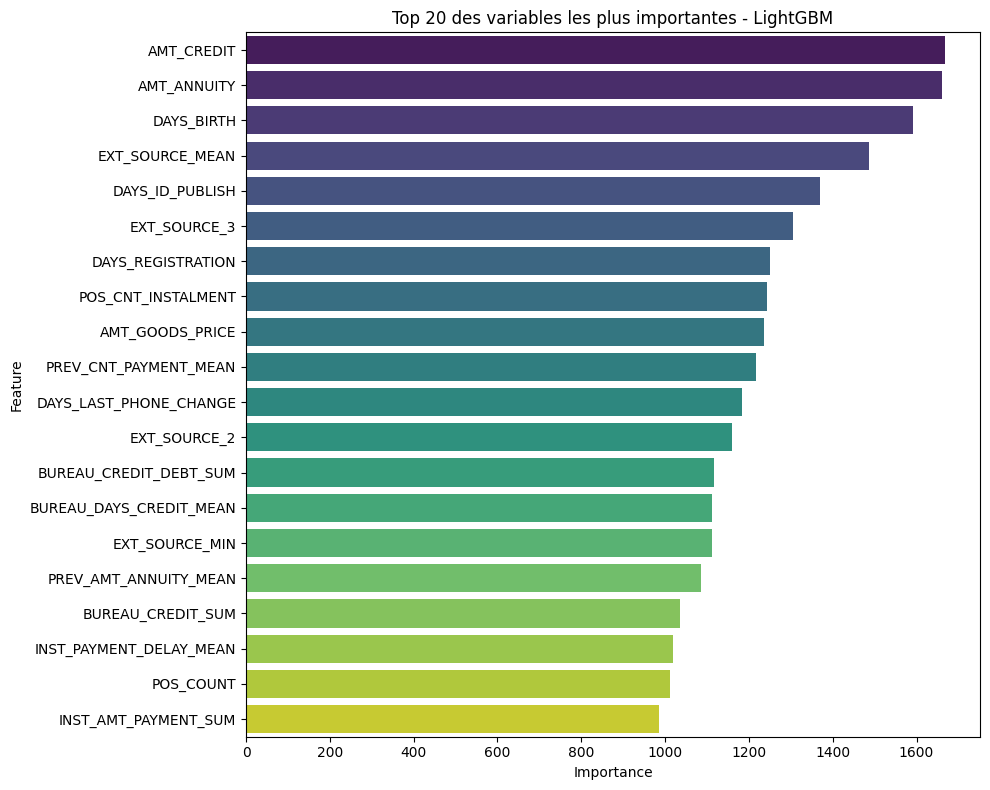

In [ ]:
# Feature importance du modele final LightGBM

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

feature_importance = pd.DataFrame({
    "feature": X.columns,
    "importance": lgbm_production.feature_importances_
}).sort_values("importance", ascending=False)

display(feature_importance.head(20))

plt.figure(figsize=(10, 8))
sns.barplot(
    data=feature_importance.head(20),
    x="importance",
    y="feature",
    palette="viridis"
)
plt.title("Top 20 des variables les plus importantes - LightGBM")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


## Importance des variables

L’analyse de l’importance des variables confirme que le modèle LightGBM s’appuie à la fois sur :
- des variables financières de la demande (`AMT_CREDIT`, `AMT_ANNUITY`, `AMT_GOODS_PRICE`) ;
- des variables socio-temporelles (`DAYS_BIRTH`, `DAYS_ID_PUBLISH`, `DAYS_REGISTRATION`, `DAYS_LAST_PHONE_CHANGE`) ;
- les scores externes (`EXT_SOURCE_*`), qui restent parmi les prédicteurs les plus influents ;
- plusieurs agrégats issus des tables secondaires, notamment sur l’historique bureau, les précédentes demandes, les échéances et les crédits renouvelables.

Ces résultats valident l’intérêt du travail de feature engineering : les variables construites à partir des sources secondaires enrichissent effectivement le modèle et complètent utilement les informations issues de la table principale.


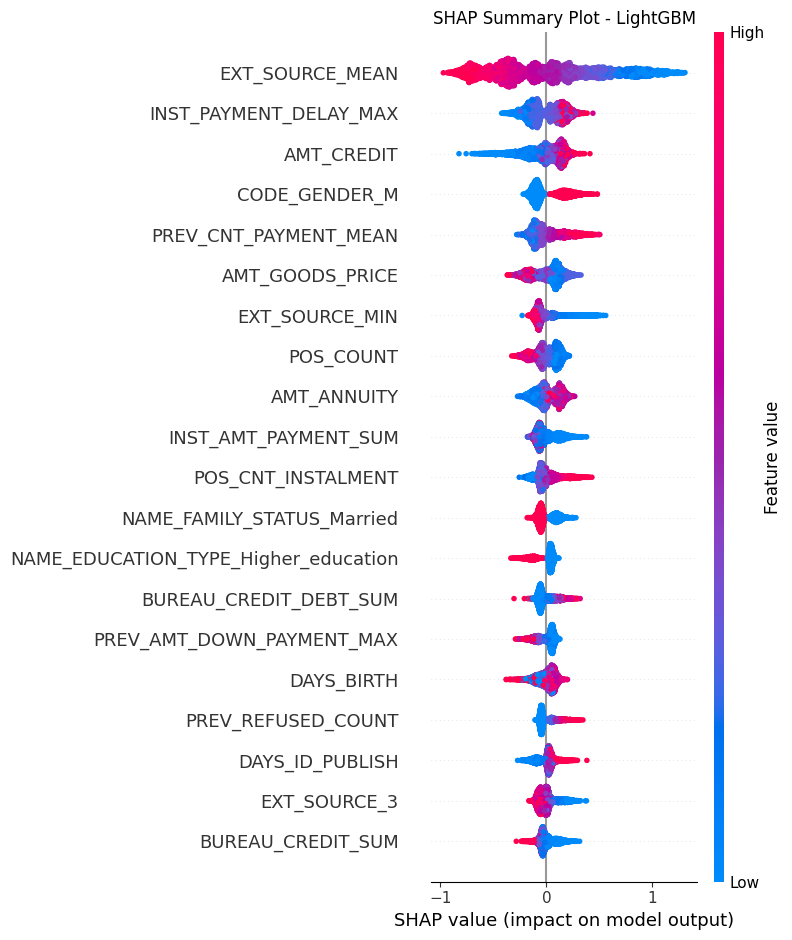

In [ ]:
# Analyse SHAP du modele final LightGBM

import shap
import matplotlib.pyplot as plt

# Echantillon pour accelerer le calcul si besoin
X_sample = X.sample(n=min(5000, len(X)), random_state=42)

# Explainer SHAP adapte aux modeles d'arbres
explainer = shap.TreeExplainer(lgbm_production)
shap_values = explainer.shap_values(X_sample)

# Pour un probleme binaire, shap_values peut etre une liste
if isinstance(shap_values, list):
    shap_values_to_plot = shap_values[1]
else:
    shap_values_to_plot = shap_values

# Summary plot global
shap.summary_plot(shap_values_to_plot, X_sample, show=False)
plt.title("SHAP Summary Plot - LightGBM")
plt.tight_layout()
plt.show()


## Interprétation SHAP

L’analyse SHAP permet d’aller plus loin que l’importance globale des variables en montrant non seulement quelles features influencent le modèle, mais aussi dans quel sens elles agissent sur la prédiction.

Le graphique met en évidence plusieurs enseignements :

- `EXT_SOURCE_MEAN` est la variable la plus influente du modèle. Des valeurs élevées de ce score externe poussent la prédiction vers un risque plus faible, tandis que des valeurs faibles augmentent la probabilité de défaut.
- `INST_PAYMENT_DELAY_MAX` confirme l’importance du comportement de remboursement : plus les retards passés sont élevés, plus le risque prédit augmente.
- `AMT_CREDIT` contribue également fortement à la décision, les montants de crédit élevés étant plutôt associés à un risque plus important.
- Les variables issues de l’historique client (`PREV_CNT_PAYMENT_MEAN`, `POS_CNT_INSTALMENT`, `PREV_REFUSED_COUNT`, `BUREAU_CREDIT_DEBT_SUM`) jouent un rôle important, ce qui valide l’intérêt du feature engineering réalisé à partir des tables secondaires.
- Les variables socio-démographiques comme `NAME_FAMILY_STATUS_Married` ou `NAME_EDUCATION_TYPE_Higher_education` apparaissent aussi dans les contributions du modèle, mais leur interprétation doit être faite avec prudence.

Globalement, l’analyse SHAP confirme que le modèle final s’appuie à la fois sur :
- la solvabilité externe (`EXT_SOURCE_*`) ;
- le comportement de paiement passé ;
- l’historique des crédits et demandes précédentes ;
- ainsi que certaines caractéristiques du profil client.

Cela renforce la cohérence métier du modèle retenu.


Client a risque eleve
Index : 156969
Probabilite predite de defaut : 0.9235


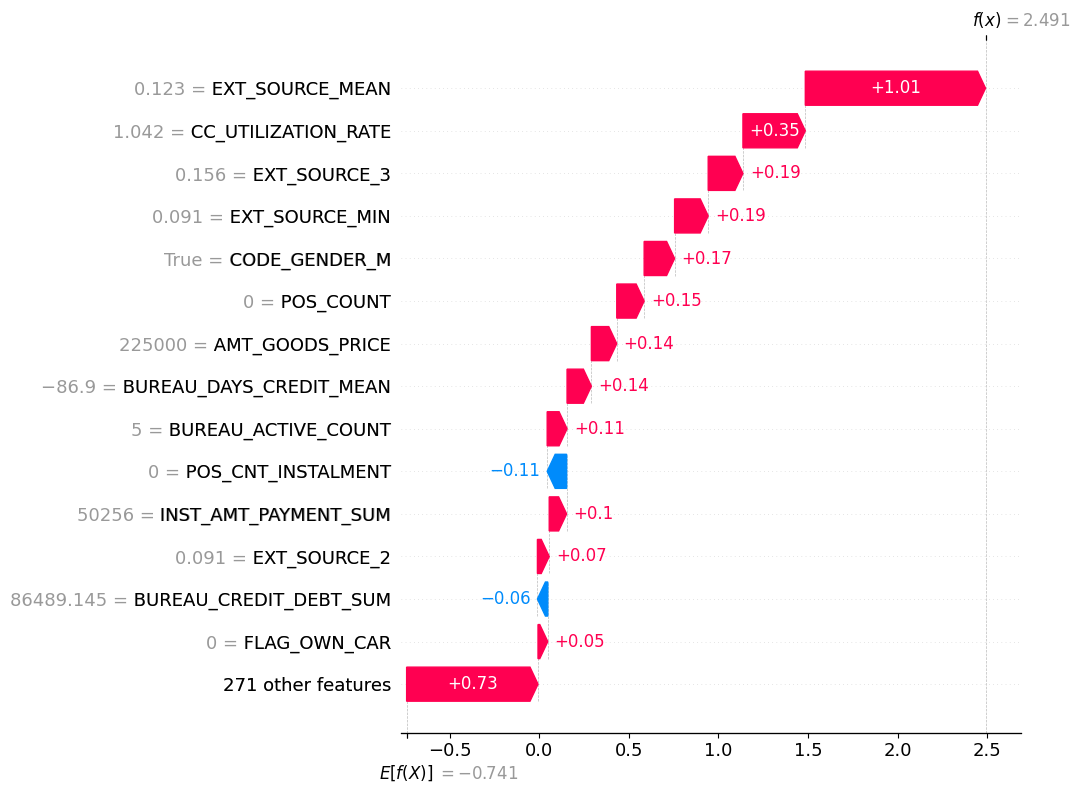

Client a risque faible
Index : 221049
Probabilite predite de defaut : 0.0209


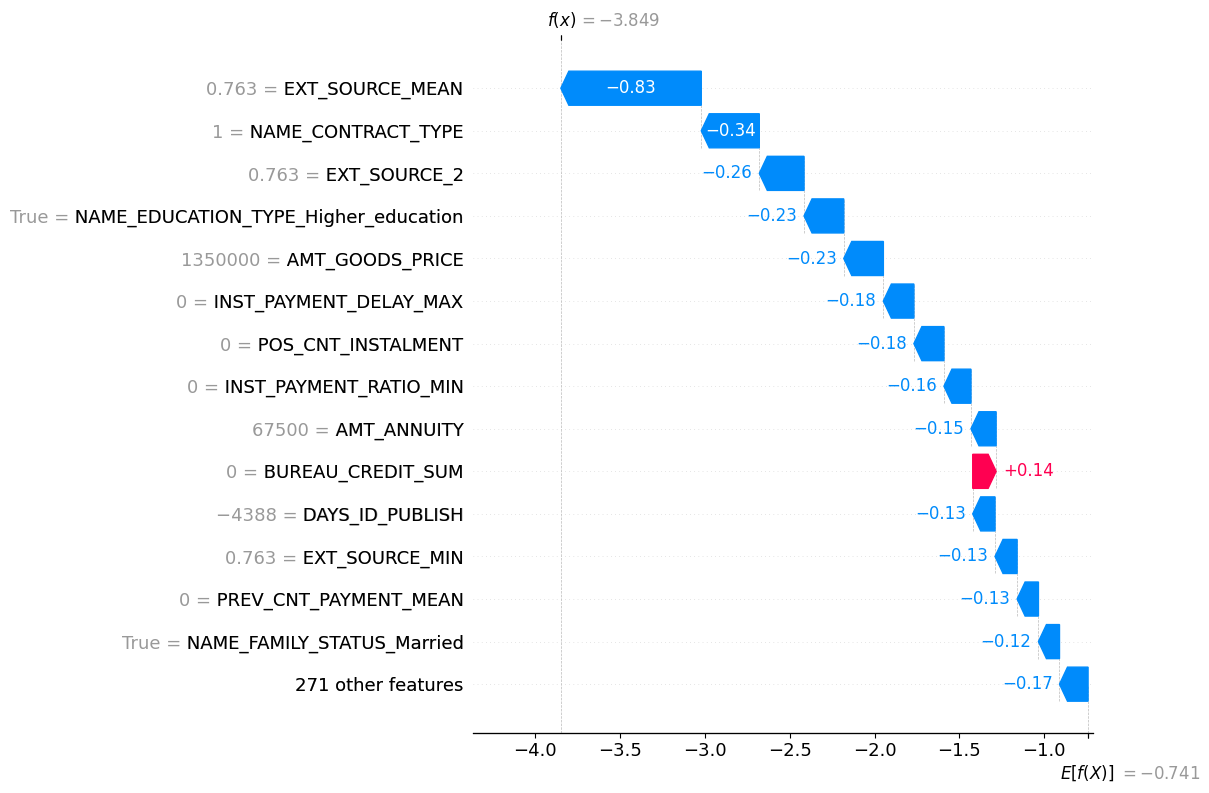

In [ ]:
# Waterfall plots SHAP pour un exemple de chaque classe predite

import shap
import matplotlib.pyplot as plt
import numpy as np

# Echantillon pour l'analyse locale
X_sample = X.sample(n=min(2000, len(X)), random_state=42)
y_proba_sample = lgbm_production.predict_proba(X_sample)[:, 1]

# Client le plus risque et le moins risque dans l'echantillon
idx_high = np.argmax(y_proba_sample)
idx_low = np.argmin(y_proba_sample)

explainer = shap.TreeExplainer(lgbm_production)
shap_values_sample = explainer.shap_values(X_sample)

if isinstance(shap_values_sample, list):
    shap_values_sample = shap_values_sample[1]
    base_value = explainer.expected_value[1]
else:
    base_value = explainer.expected_value

for label, idx in [("Client a risque eleve", idx_high), ("Client a risque faible", idx_low)]:
    x_local = X_sample.iloc[[idx]]

    print("=" * 80)
    print(label)
    print("Index :", X_sample.index[idx])
    print("Probabilite predite de defaut :", round(float(y_proba_sample[idx]), 4))

    shap_explanation = shap.Explanation(
        values=shap_values_sample[idx],
        base_values=base_value,
        data=x_local.iloc[0],
        feature_names=x_local.columns.tolist()
    )

    shap.plots.waterfall(shap_explanation, max_display=15)
    plt.show()


## Explicabilité locale avec SHAP

Deux graphiques waterfall ont été produits pour illustrer le fonctionnement du modèle sur des cas individuels : un client à risque élevé et un client à faible risque.

Dans le cas du client à risque élevé, la prédiction est principalement tirée vers le défaut par :
- un `EXT_SOURCE_MEAN` faible ;
- un taux d’utilisation de crédit élevé (`CC_UTILIZATION_RATE`) ;
- des scores externes faibles (`EXT_SOURCE_2`, `EXT_SOURCE_3`, `EXT_SOURCE_MIN`) ;
- ainsi que plusieurs signaux issus de l’historique de crédit.

À l’inverse, pour le client à faible risque, la prédiction est fortement tirée vers le non-défaut par :
- un `EXT_SOURCE_MEAN` élevé ;
- de bons scores externes ;
- l’absence de retard de paiement ;
- et certaines caractéristiques de profil plus favorables.

Ces graphiques montrent que le modèle peut être interprété à l’échelle individuelle : il est possible d’identifier les principales variables qui poussent une prédiction vers un risque plus élevé ou plus faible. Cela renforce la lisibilité du modèle retenu et constitue un atout important dans un contexte de scoring crédit.


## Conclusion

Ce notebook a permis de comparer plusieurs approches de modélisation pour le scoring crédit : régression logistique, LightGBM, XGBoost et MLP.

Les résultats montrent que **LightGBM** est le modèle le plus performant sur ce projet. Il obtient le meilleur compromis entre **AUC** et **coût métier**, ce qui en fait le candidat le plus pertinent pour la suite. XGBoost obtient des performances proches, tandis que la régression logistique et le MLP restent légèrement en retrait.

Une optimisation des hyperparamètres avec **Optuna** a ensuite été menée sur LightGBM. Deux stratégies ont été comparées :
- une optimisation basée sur l’**AUC** ;
- une optimisation basée sur le **coût métier**.

Les configurations obtenues sont restées relativement proches, ce qui suggère que, sur ce dataset, l’AUC constitue un bon proxy de l’objectif métier. L’optimisation directe sur le coût métier reste néanmoins la plus alignée avec le besoin opérationnel.

Le travail d’exploration a également permis d’enrichir l’analyse du MLP. Le test de plusieurs fonctions d’activation a montré que **`logistic`** donnait de meilleurs résultats que `relu` et `tanh` dans cette configuration. Malgré cette amélioration, le MLP demeure moins performant que les modèles de boosting sur ces données tabulaires.

Le modèle final retenu est donc un **LightGBM optimisé**, réentraîné sur **100 % des données**, puis enregistré dans le **Model Registry MLflow** sous le nom `home_credit_scoring`. Cette étape garantit la traçabilité, le versioning et la réutilisation du modèle dans la suite du projet.

Enfin, l’interprétation du modèle a confirmé sa cohérence métier :
- la **feature importance** met en avant à la fois des variables financières, temporelles et des agrégats issus des tables secondaires ;
- l’analyse **SHAP globale** montre que les scores externes (`EXT_SOURCE_*`) dominent la prédiction, devant plusieurs variables liées à l’historique de paiement et de crédit ;
- les explications **SHAP locales** permettent d’illustrer, au niveau individuel, pourquoi un client est jugé plus ou moins risqué.

Le notebook aboutit ainsi à un modèle à la fois **performant, traçable et interprétable**, prêt à être exploité dans l’étape suivante du projet, notamment via son intégration dans l’API.
